In [40]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.patches import Patch

from src.config import DISTORTION_LABELS, LABEL2ID, SEED

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(SEED)

print('All imports successful.')
print(f'Labels ({len(DISTORTION_LABELS)}):', DISTORTION_LABELS)

All imports successful.
Labels (10): ['All-or-nothing thinking', 'Overgeneralization', 'Mental filter', 'Should statements', 'Labeling', 'Personalization', 'Catastrophising/Magnification', 'Emotional Reasoning', 'Mind Reading', 'Fortune-telling']


In [41]:
CSV_PATH = '../data/raw/Annotated_data.csv'

full_df = pd.read_csv(CSV_PATH, encoding='utf-8')

print('Shape:', full_df.shape)
print('Columns:', full_df.columns.tolist())
print()
full_df.head(3)

Shape: (2530, 5)
Columns: ['Id_Number', 'Patient Question', 'Distorted part', 'Dominant Distortion', 'Secondary Distortion (Optional)']



,Id_Number,Patient Question,Distorted part,Dominant Distortion,Secondary Distortion (Optional)
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalization,NaN
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Labeling,Emotional Reasoning
2,4502,So I’ve been dating on and off this guy for a...,NaN,No Distortion,NaN


In [42]:
print('Actual columns in CSV:', full_df.columns.tolist())

rename_map = {}
for col in full_df.columns:
    col_lower = col.lower().strip()
    if 'patient question' in col_lower:
        rename_map[col] = 'text'
    elif 'dominant' in col_lower:
        rename_map[col] = 'dominant_distortion'
    elif 'secondary' in col_lower:
        rename_map[col] = 'secondary_distortion'
    elif 'distorted part' in col_lower:
        rename_map[col] = 'distorted_part'

full_df = full_df.rename(columns=rename_map)
print('Renamed to:', full_df.columns.tolist())

full_df['text'] = full_df['text'].astype(str).str.strip()
full_df['dominant_distortion'] = full_df['dominant_distortion'].astype(str).str.strip()

if 'secondary_distortion' in full_df.columns:
    full_df['secondary_distortion'] = full_df['secondary_distortion'].astype(str).str.strip()
else:
    full_df['secondary_distortion'] = ''
    print('Note: No secondary distortion column found - added as empty.')

print('\nNull counts:')
print(full_df.isnull().sum())
print()
print('Unique dominant_distortion values:')
print(sorted(full_df['dominant_distortion'].unique()))

Actual columns in CSV: ['Id_Number', 'Patient Question', 'Distorted part', 'Dominant Distortion', 'Secondary Distortion (Optional)']
Renamed to: ['Id_Number', 'text', 'distorted_part', 'dominant_distortion', 'secondary_distortion']

Null counts:
Id_Number                  0
text                       0
distorted_part           933
dominant_distortion        0
secondary_distortion    2114
dtype: int64

Unique dominant_distortion values:
['All-or-nothing thinking', 'Emotional Reasoning', 'Fortune-telling', 'Labeling', 'Magnification', 'Mental filter', 'Mind Reading', 'No Distortion', 'Overgeneralization', 'Personalization', 'Should statements']


In [43]:
# Train-test split on dominant_distortion (80/20)
train_df, test_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=SEED,
    stratify=full_df['dominant_distortion']
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train size : {len(train_df)}')
print(f'Test size  : {len(test_df)}')
print(f'Total      : {len(full_df)}')

Train size : 2024
Test size  : 506
Total      : 2530


In [44]:
label_counts = full_df['dominant_distortion'].value_counts()
print('Label counts (dominant distortion):')
print(label_counts.to_string())
print(f'\n"No distortion" examples : {label_counts.get("No distortion", 0)}')

Label counts (dominant distortion):
dominant_distortion
No Distortion              933
Mind Reading               239
Overgeneralization         239
Magnification              195
Labeling                   165
Personalization            153
Fortune-telling            143
Emotional Reasoning        134
Mental filter              122
Should statements          107
All-or-nothing thinking    100

"No distortion" examples : 0


C:\Users\HP\AppData\Local\Temp\ipykernel_19560\864606333.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_counts.index, rotation=40, ha='right', fontsize=10)


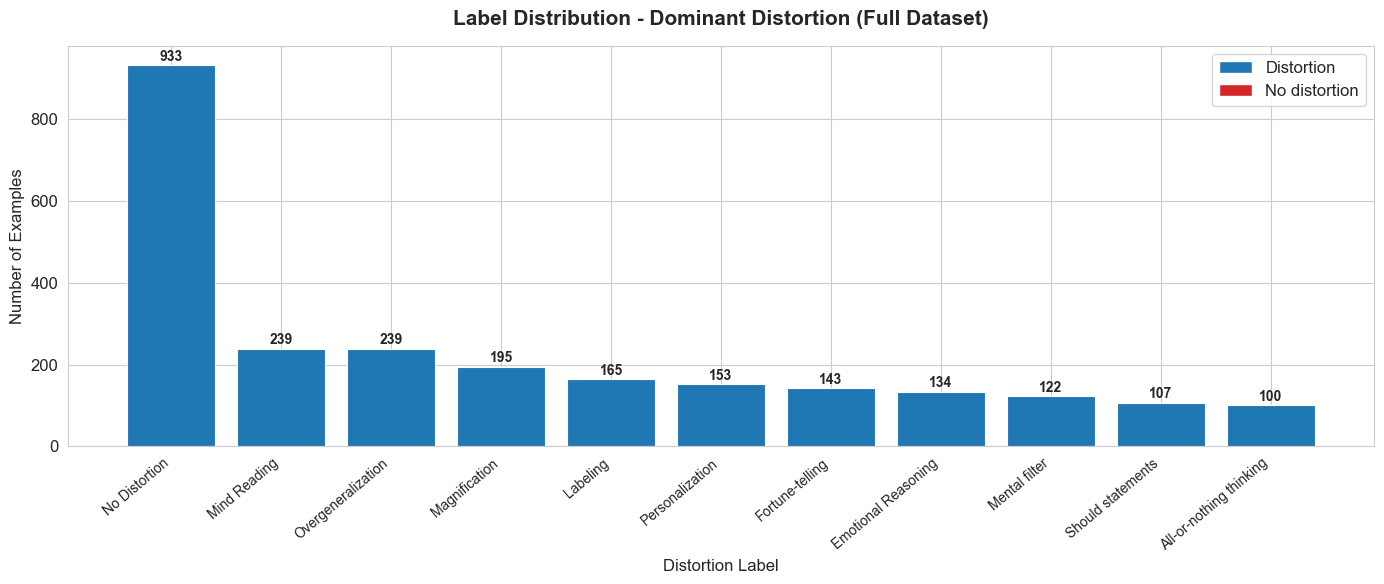

Saved: results/label_distribution.png


In [45]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#d62728' if label == 'No distortion' else '#1f77b4' for label in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Label Distribution - Dominant Distortion (Full Dataset)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Distortion Label', fontsize=12)
ax.set_ylabel('Number of Examples', fontsize=12)
ax.set_xticklabels(label_counts.index, rotation=40, ha='right', fontsize=10)

legend_elements = [Patch(facecolor='#1f77b4', label='Distortion'), Patch(facecolor='#d62728', label='No distortion')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/label_distribution.png')

In [46]:
distortion_only   = full_df[full_df['dominant_distortion'] != 'No distortion']
distortion_counts = distortion_only['dominant_distortion'].value_counts()

max_count       = distortion_counts.max()
min_count       = distortion_counts.min()
imbalance_ratio = max_count / min_count

print(f'Most common label : {distortion_counts.idxmax()} ({max_count} examples)')
print(f'Rarest label      : {distortion_counts.idxmin()} ({min_count} examples)')
print(f'Imbalance ratio   : {imbalance_ratio:.1f}x')
print(f'\nPercentage breakdown (distortion labels only):')
print((distortion_counts / distortion_counts.sum() * 100).round(1).to_string())

Most common label : No Distortion (933 examples)
Rarest label      : All-or-nothing thinking (100 examples)
Imbalance ratio   : 9.3x

Percentage breakdown (distortion labels only):
dominant_distortion
No Distortion              36.9
Mind Reading                9.4
Overgeneralization          9.4
Magnification               7.7
Labeling                    6.5
Personalization             6.0
Fortune-telling             5.7
Emotional Reasoning         5.3
Mental filter               4.8
Should statements           4.2
All-or-nothing thinking     4.0


In [47]:
unique_labels = np.array(distortion_counts.index.tolist())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=distortion_only['dominant_distortion'].values
)

weight_df = pd.DataFrame({'Label': unique_labels, 'Class Weight': class_weights.round(3)})
weight_df = weight_df.sort_values('Class Weight', ascending=False).reset_index(drop=True)
print('Class weights (higher = rarer label = penalised more if missed):')
print(weight_df.to_string(index=False))

Class weights (higher = rarer label = penalised more if missed):
                  Label  Class Weight
All-or-nothing thinking         2.300
      Should statements         2.150
          Mental filter         1.885
    Emotional Reasoning         1.716
        Fortune-telling         1.608
        Personalization         1.503
               Labeling         1.394
          Magnification         1.179
           Mind Reading         0.962
     Overgeneralization         0.962
          No Distortion         0.247


In [48]:
has_secondary = full_df['secondary_distortion'].notna() & \
                ~full_df['secondary_distortion'].isin(['nan', '', 'None', 'NaN'])

print(f'Examples with a secondary distortion : {has_secondary.sum()}')
print(f'Examples with only one label         : {(~has_secondary).sum()}')
print(f'Multi-label percentage               : {has_secondary.mean()*100:.1f}%')

if has_secondary.sum() > 0:
    print('\nSecondary label distribution:')
    print(full_df.loc[has_secondary, 'secondary_distortion'].value_counts().to_string())

Examples with a secondary distortion : 416
Examples with only one label         : 2114
Multi-label percentage               : 16.4%

Secondary label distribution:
secondary_distortion
Fortune-telling            67
Mind Reading               56
Magnification              50
Personalization            49
Overgeneralization         38
Labeling                   38
Emotional Reasoning        35
Mental filter              29
Should statements          28
All-or-nothing thinking    26


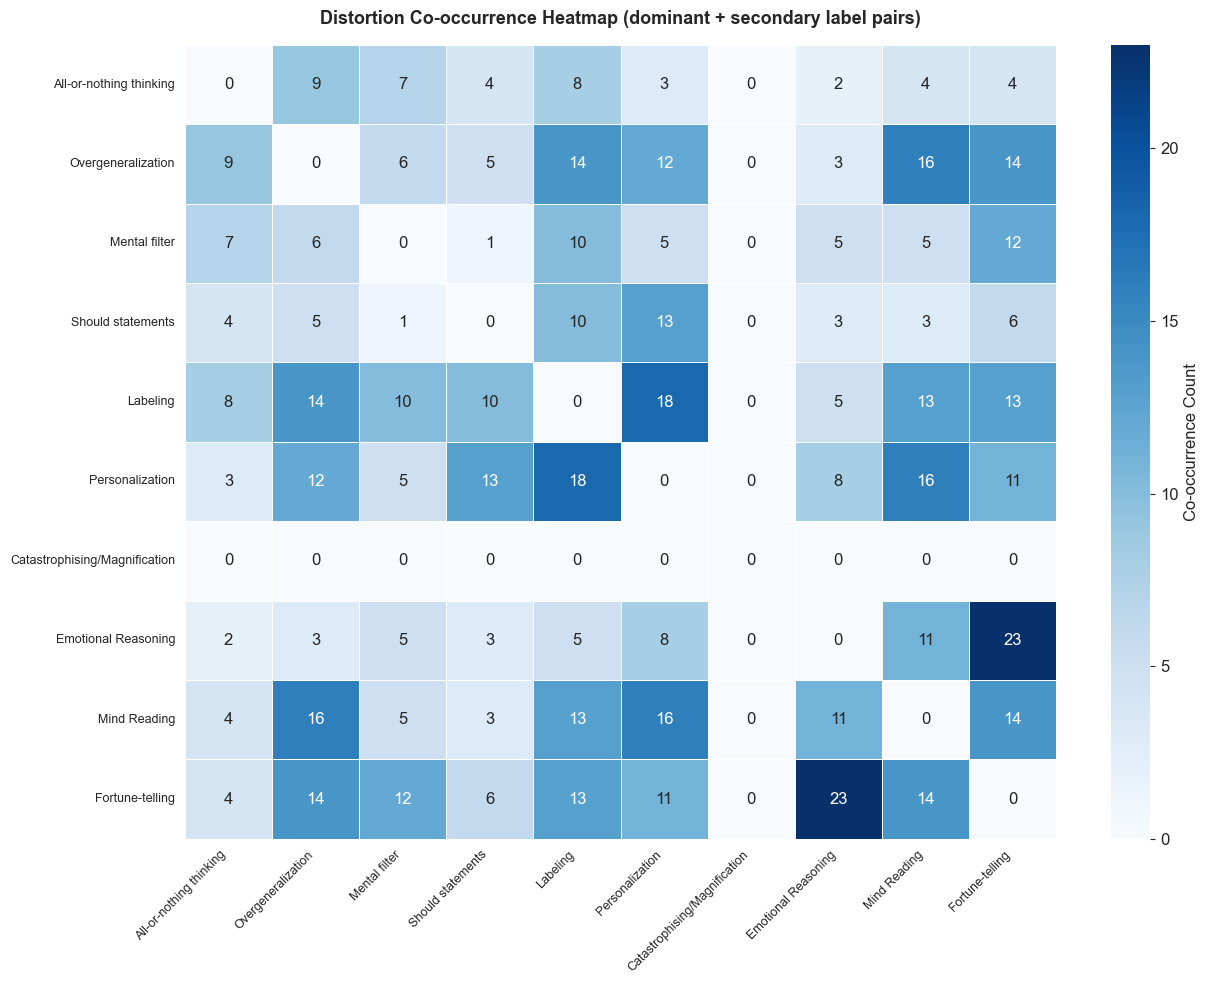

Saved: results/cooccurrence_heatmap.png


In [49]:
cooc = np.zeros((len(DISTORTION_LABELS), len(DISTORTION_LABELS)), dtype=int)

for _, row in full_df.iterrows():
    dom = row['dominant_distortion']
    sec = row['secondary_distortion']
    if dom in LABEL2ID and sec in LABEL2ID:
        i, j = LABEL2ID[dom], LABEL2ID[sec]
        cooc[i][j] += 1
        cooc[j][i] += 1

cooc_df = pd.DataFrame(cooc, index=DISTORTION_LABELS, columns=DISTORTION_LABELS)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cooc_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-occurrence Count'})
ax.set_title('Distortion Co-occurrence Heatmap (dominant + secondary label pairs)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../results/cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/cooccurrence_heatmap.png')

In [50]:
full_df['word_count'] = full_df['text'].str.split().str.len()
full_df['char_count'] = full_df['text'].str.len()

print('Text length statistics (words):')
print(full_df['word_count'].describe().round(1).to_string())
print(f'\nExamples > 380 words (near DistilBERT limit) : {(full_df["word_count"] > 380).sum()}')
print(f'Percentage                                    : {(full_df["word_count"] > 380).mean()*100:.1f}%')

Text length statistics (words):
count    2530.0
mean      167.4
std       114.5
min        29.0
25%        82.0
50%       127.0
75%       223.8
max      1059.0

Examples > 380 words (near DistilBERT limit) : 192
Percentage                                    : 7.6%


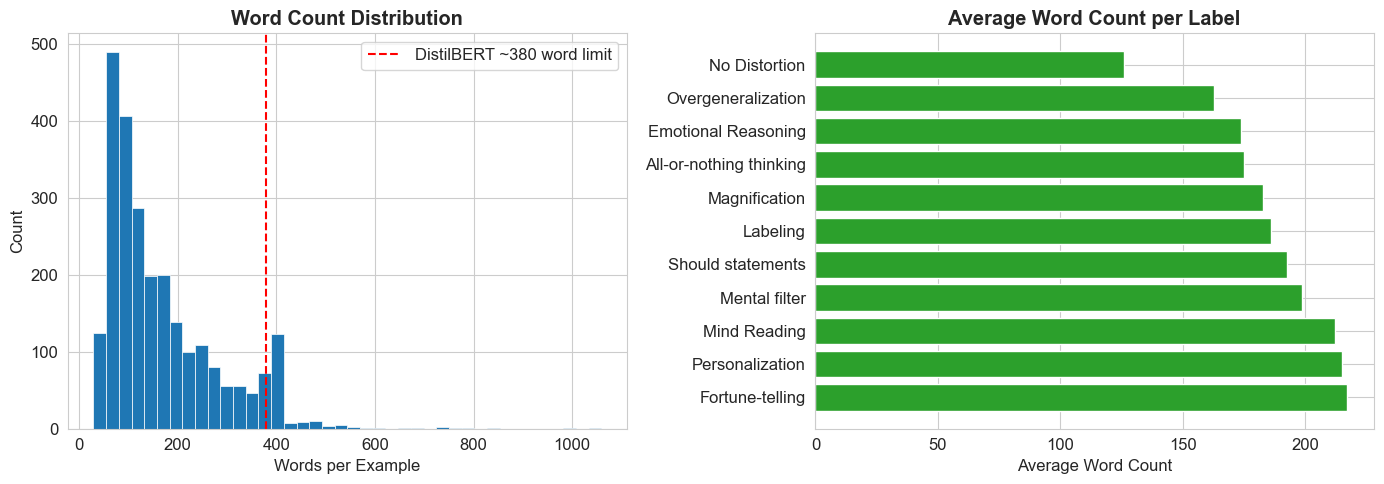

Saved: results/text_length_analysis.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(full_df['word_count'], bins=40, color='#1f77b4', edgecolor='white', linewidth=0.5)
axes[0].axvline(380, color='red', linestyle='--', linewidth=1.5, label='DistilBERT ~380 word limit')
axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per Example')
axes[0].set_ylabel('Count')
axes[0].legend()

label_wc = (
    full_df[full_df['dominant_distortion'] != 'No distortion']
    .groupby('dominant_distortion')['word_count']
    .mean()
    .sort_values(ascending=False)
)
axes[1].barh(label_wc.index, label_wc.values, color='#2ca02c', edgecolor='white')
axes[1].set_title('Average Word Count per Label', fontweight='bold')
axes[1].set_xlabel('Average Word Count')

plt.tight_layout()
plt.savefig('../results/text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/text_length_analysis.png')

In [52]:
train_pct = train_df['dominant_distortion'].value_counts(normalize=True) * 100
test_pct  = test_df['dominant_distortion'].value_counts(normalize=True) * 100

split_check = pd.DataFrame({
    'Train %' : train_pct.round(1),
    'Test %'  : test_pct.round(1)
}).dropna()
split_check['Diff'] = (split_check['Train %'] - split_check['Test %']).abs().round(1)

print('Train vs Test label proportions:')
print(split_check.to_string())

Train vs Test label proportions:
                         Train %  Test %  Diff
dominant_distortion                           
No Distortion               36.9    37.0   0.1
Mind Reading                 9.4     9.5   0.1
Overgeneralization           9.4     9.5   0.1
Magnification                7.7     7.7   0.0
Labeling                     6.5     6.5   0.0
Personalization              6.0     6.1   0.1
Fortune-telling              5.7     5.5   0.2
Emotional Reasoning          5.3     5.3   0.0
Mental filter                4.8     4.7   0.1
Should statements            4.2     4.2   0.0
All-or-nothing thinking      4.0     4.0   0.0


In [53]:
print('-' * 60)
print('EDA SUMMARY - KEY FINDINGS')
print('-' * 60)
print(f"""
Dataset:
  Total examples     : {len(full_df)}
  Train / Test split : {len(train_df)} / {len(test_df)} (80/20 stratified)

Labels:
  Most common label  : {distortion_counts.idxmax()} ({distortion_counts.max()} examples)
  Rarest label       : {distortion_counts.idxmin()} ({distortion_counts.min()} examples)
  Imbalance ratio    : {imbalance_ratio:.1f}x
  'No distortion'    : {label_counts.get('No distortion', 0)} examples
  Multi-label (2 labels) : {has_secondary.sum()} examples ({has_secondary.mean()*100:.1f}%)

Text:
  Median word count  : {full_df['word_count'].median():.0f} words
  Max word count     : {full_df['word_count'].max()} words
  Above 380 words    : {(full_df['word_count'] > 380).sum()} examples ({(full_df['word_count'] > 380).mean()*100:.1f}%)

Training decisions confirmed:
  -> Use class weights in loss function
  -> DistilBERT truncation to 512 tokens covers most examples
  -> Multi-label format needed (dominant + secondary)
""")
print('-' * 60)

------------------------------------------------------------
EDA SUMMARY - KEY FINDINGS
------------------------------------------------------------

Dataset:
  Total examples     : 2530
  Train / Test split : 2024 / 506 (80/20 stratified)

Labels:
  Most common label  : No Distortion (933 examples)
  Rarest label       : All-or-nothing thinking (100 examples)
  Imbalance ratio    : 9.3x
  'No distortion'    : 0 examples
  Multi-label (2 labels) : 416 examples (16.4%)

Text:
  Median word count  : 127 words
  Max word count     : 1059 words
  Above 380 words    : 192 examples (7.6%)

Training decisions confirmed:
  -> Use class weights in loss function
  -> DistilBERT truncation to 512 tokens covers most examples
  -> Multi-label format needed (dominant + secondary)

------------------------------------------------------------
